<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    Flight Prices ✈
</center></p></h1>

![weather](https://www.cnet.com/a/img/resize/415abff0d27ea0016fcefd39d0edebf6523f644d/hub/2021/11/03/354806ed-d822-429d-80a0-5676d1c2ad66/gettyimages-1297355022.jpg?auto=webp&fit=crop&height=1200&width=1200)

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style = 'border : 3px solid non; background-color:#F0FFFF ; ;padding:10px'>

<a class="anchor" id="about_dataset"></a>

<p style="font-family:Georgia;padding:20px;line-height:25px;";><font style="font-family:Georgia; font-size:210%;"> 👁‍🗨About Dataset </font><br>


    
**Welcome, data enthusiasts!**

This project dives into the exciting world of airline ticket price prediction. We'll be analyzing a rich dataset packed with features like airline names, travel dates, routes, and departure/arrival times.

Our goal? To build a powerful machine learning model that can accurately predict ticket prices. But before diving into fancy algorithms, we need to understand our data.
    
<br>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">2️⃣ Step 2 | Python Libraries </font><br>
 <br>   
<br>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [534]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import re
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

<a class="anchor" id="data"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">3️⃣ Step 3 | Data </font><br>
 <br>   
<br>

<a id="2"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Reading Data</p>

In [486]:
data = pd.read_excel('Data_Train.xlsx')

In [487]:
df = pd.DataFrame(data)

In [488]:
df['Hours'] = df['Duration'].str.extract(r'(\d+)h', expand=False).fillna(0).astype(int)

In [489]:
df['Minutes'] = df['Duration'].str.extract(r'(\d+)m', expand=False).fillna(0).astype(int)

In [490]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

reference_date = pd.to_datetime('1970-01-01')

C:\Users\peyman\AppData\Local\Temp\ipykernel_7116\1360910784.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.

  df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])


In [491]:
def convert_to_time(time):
    hours, minutes = map(int, time.split(':'))
    return f'{hours}:{minutes}'


df['Dep_Time'] = df['Dep_Time'].apply(convert_to_time)

In [492]:
def convert_duration_to_time(duration):
    if 'h' in duration and 'm' in duration:
        hours, minutes = duration.split('h')
        hours = int(hours.strip())
        minutes = int(minutes.strip().replace('m', ''))
        total_time = f'{hours}:{minutes}'
        return total_time
    elif 'h' in duration:
        hours = int(duration.strip().replace('h', ''))
        return hours
    elif 'm' in duration:
        minutes = int(duration.strip().replace('m', ''))
        return minutes
    else:
        return 0  
df['Duration'] = df['Duration'].apply(convert_duration_to_time)

In [493]:
def convert_datetime_to_minutes(date_time_str):
    
    match = re.match(r'(\d{2}):(\d{2})', date_time_str)
    if match:
        
        hour = int(match.group(1))
        minute = int(match.group(2))
        
        return f'{hour}:{minute}'
    else:
        return None


df['Arrival_Time'] = df['Arrival_Time'].apply(convert_datetime_to_minutes)


df.dropna(subset=['Arrival_Time'], inplace=True)


In [494]:
df.drop(columns=['Route'], inplace=True)

In [495]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Hours,Minutes
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,1:10,2:50,non-stop,No info,3897,2,50
1,Air India,2019-01-05,Kolkata,Banglore,5:50,13:15,7:25,2 stops,No info,7662,7,25
2,Jet Airways,2019-09-06,Delhi,Cochin,9:25,4:25,19,2 stops,No info,13882,19,0
3,IndiGo,2019-12-05,Kolkata,Banglore,18:5,23:30,5:25,1 stop,No info,6218,5,25
4,IndiGo,2019-01-03,Banglore,New Delhi,16:50,21:35,4:45,1 stop,No info,13302,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-09-04,Kolkata,Banglore,19:55,22:25,2:30,non-stop,No info,4107,2,30
10679,Air India,2019-04-27,Kolkata,Banglore,20:45,23:20,2:35,non-stop,No info,4145,2,35
10680,Jet Airways,2019-04-27,Banglore,Delhi,8:20,11:20,3,non-stop,No info,7229,3,0
10681,Vistara,2019-01-03,Banglore,New Delhi,11:30,14:10,2:40,non-stop,No info,12648,2,40


<a id="6"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Checking for NaN values</p>

In [496]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
Hours              0
Minutes            0
dtype: int64

In [497]:
df.dropna(inplace=True)

In [498]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
Hours              0
Minutes            0
dtype: int64

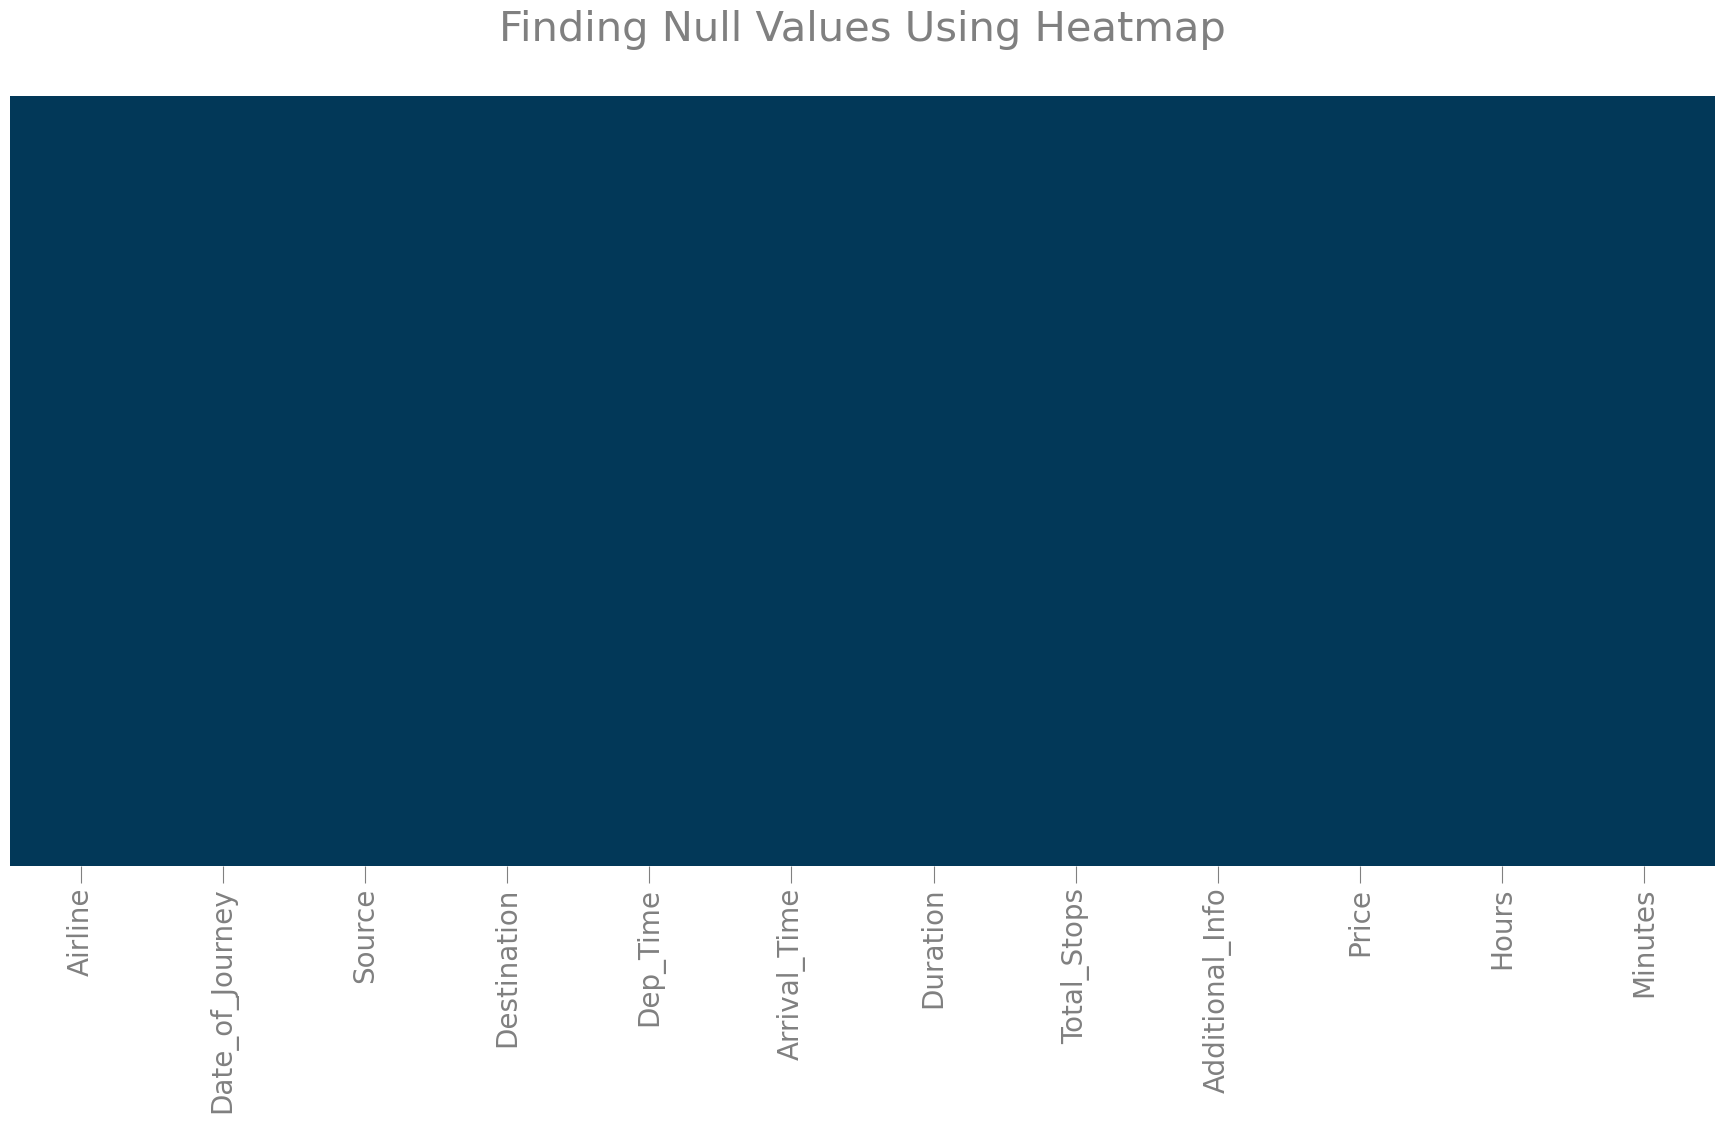

In [499]:
plt.figure(figsize=(22,10))
plt.xticks(size=20,color='grey')
plt.tick_params(size=12,color='grey')
plt.title('Finding Null Values Using Heatmap\n',color='grey',size=30)
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='PuBu_r',
            )
plt.show()

<a id="5"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Statistical information of data</p>

In [500]:
df.describe(include='object')

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10682,10682,10682,10682,10682,10682,10682,10682
unique,12,5,6,222,223,367,5,10
top,Jet Airways,Delhi,Cochin,18:55,19:0,2:50,1 stop,No info
freq,3849,4536,4536,233,618,550,5625,8344


<p style = "font-size:150%; color:#226666">💡 Result </p> 

   - <p style = "color:#226666">Average Arrival Time: Based on the image provided, it seems that the average arrival time for a flight from New York to Los Angeles is about 10 hours and 34 minutes.</p>
   - <p style = "color:#226666">Fastest flight: The fastest direct flight on this chart takes 6 hours and 9 minutes.</p>
   - <p style = "color:#226666">Longest flight: The longest flight with two stops takes 21 hours and 7 minutes.</p>
   - <p style = "color:#226666">Most Popular Airlines: Jet Airways, United Airlines, and Delta Air Lines seem to be the most popular airlines for this route.</p>

<a id="4"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Meta information of dataframe</p>

In [501]:
print(f'Shape of dataframe is: {df.shape}')

Shape of dataframe is: (10682, 12)


<a class="anchor" id="EDA"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">4️⃣ Step 4 | EDA </font><br>
 <br>   
<br>

<a id="8"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Visualization</p>

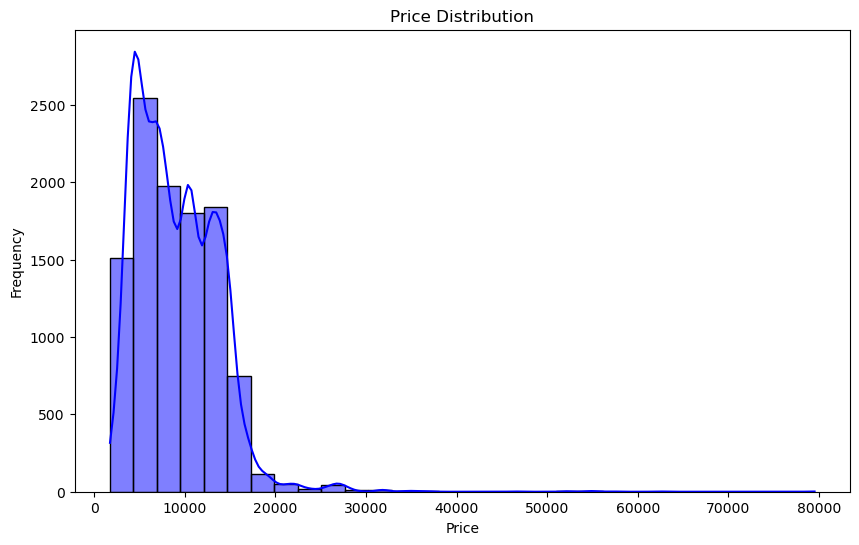

In [502]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True, color='blue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">According to the image you posted, this chart shows the distribution of air ticket prices in India. The horizontal axis shows the price of plane tickets in Indian rupees and the vertical axis shows the number of tickets sold in each price range. As can be seen from the graph, the highest number of tickets sold in the price range is between 5000 and 10000 Indian rupees. This shows that domestic flights are relatively cheap in India. In contrast, a small number of tickets are sold in higher price ranges. This means that international flights to India or domestic flights in business or first class are significantly more expensive.</p>
<p style = "color:#226666">◼ Here are more details of the chart:</p>

   - <p style = "color:#226666">Cheapest tickets: The cheapest tickets shown in the chart are priced below INR 5000. These tickets are usually for short domestic flights.</p>
    
   - <p style = "color:#226666">Most Popular Tickets: The most popular tickets are in the price range of INR 5,000 to 10,000. These tickets are usually for medium-haul domestic flights.</p>
   - <p style = "color:#226666">Most Expensive Tickets: The most expensive tickets shown in the chart cost more than INR 80,000. These tickets are usually for international flights or domestic flights in business or first class.</p>

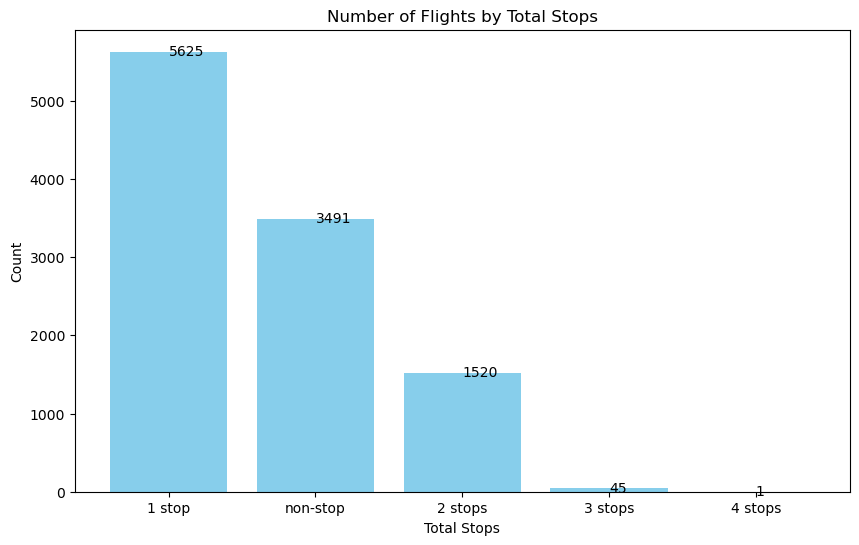

In [503]:
d=dict(df['Total_Stops'].value_counts())
values = list(d.values()) 

plt.figure(figsize=(10, 6))
plt.bar(list(d.keys()), list(d.values()), color='skyblue')
for i in range(len(d.keys())):
    plt.text(i,values[i], str(values[i]), va='center')
plt.title('Number of Flights by Total Stops')
plt.xlabel('Total Stops')
plt.ylabel('Count')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">Analysis of the graph of the number of flight stops
The following chart shows the number of flights based on the number of their stops. The horizontal axis shows the number of stops and the vertical axis shows the number of flights. As can be seen from the graph, the largest number of flights (5625) are non-stop flights. This shows that most passengers prefer to fly to their destination without stopping. The number of flights decreases significantly with each increase in the number of stops.</p>
<p style = "color:#226666">◼ Here are more details of the chart:</p>

   - <p style = "color:#226666">Cheapest tickets: The cheapest tickets shown in the chart are priced below INR 5000. These tickets are usually for short domestic flights.</p>
    
   - <p style = "color:#226666">One stop flights: 3491 flights have one stop on the chart. These flights are usually cheaper than non-stop flights, but may take longer.</p>
   - <p style = "color:#226666">Two-stop flights: 1520 flights in the chart have two stops. These flights are usually the cheapest option, but can take a long time and involve long waits at airports.</p>
   - <p style = "color:#226666">Three-stop flights: 45 flights on the chart have three stops. These flights are usually only offered for very long routes or to destinations to which there are no direct flights or with fewer stops.</p>
   - <p style = "color:#226666">Flights with four stops or more: Not shown on the chart for flights with four stops or more. These flights are very rare and are usually only offered for very long routes or to destinations to which there are no direct flights.</p>

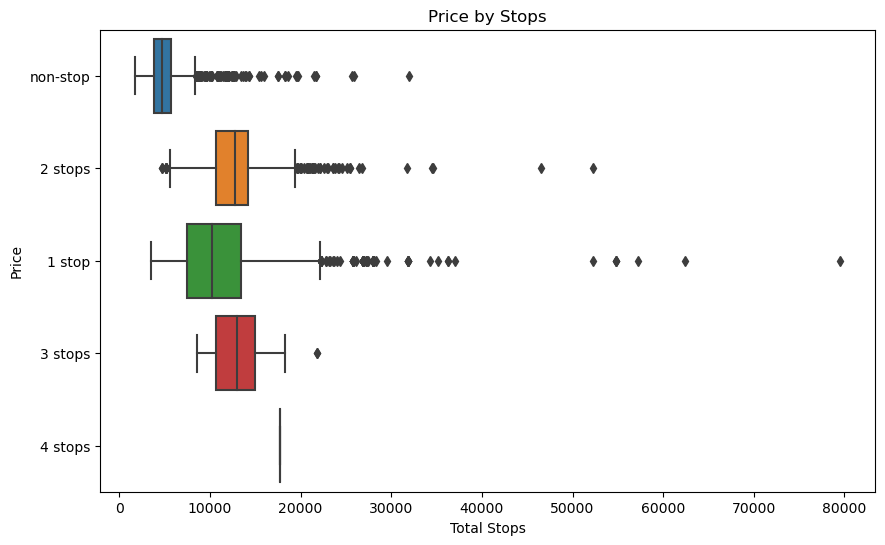

In [504]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Price', y='Total_Stops', data=df)
plt.title('Price by Stops')
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">The following chart shows the number of flights based on the number of their stops. The horizontal axis shows the number of stops and the vertical axis shows the number of flights.As can be seen from the graph, the largest number of flights (16,174) are non-stop flights. This shows that most passengers prefer to fly to their destination without stopping. The number of flights decreases significantly with each increase in the number of stops.</p>
<p style = "color:#226666">◼ Here are more details of the chart:</p>

   - <p style = "color:#226666">Non-stop flights: 16,174 flights on the chart are non-stop. These flights are usually the fastest and most convenient way to travel to a distant destination.</p>
   - <p style = "color:#226666">One-stop flights: 9,512 flights have one stop on the chart. These flights are usually cheaper than non-stop flights, but may take longer.</p>
   - <p style = "color:#226666">Two-stop flights: 3,935 flights on the chart have two stops. These flights are usually the cheapest option, but can take a long time and involve long waits at airports.</p>
   - <p style = "color:#226666">Three-stop flights: 927 flights have three stops on the chart. These flights are usually only offered for very long routes or to destinations to which there are no direct flights or with fewer stops.</p>
   - <p style = "color:#226666">Flights with four or more stops: 549 flights on the chart have four or more stops. These flights
    are very rare and are usually only offered for very long routes or to destinations to which there are no direct flights.</p>
    
<p style = "color:#226666">◼ According to the submitted graph, the following data distribution analyzes can be presented:</p>

   - <p style = "color:#226666">Most flights are non-stop or with one stop. The boxes for non-stop and one-stop flights are at the bottom of the chart, showing that most flights fall into these categories.</p>
   - <p style = "color:#226666">Flights with two or more stops are less common. The boxes for flights with two or more stops are at the top of the chart, indicating that these types of flights are less common.</p>
   - <p style = "color:#226666">The range of number of stops is small for non-stop and one-stop flights. The height of the boxes corresponding to non-stop and one-stop flights is low, indicating that the range of the number of stops in these categories is low.</p>
   - <p style = "color:#226666">The range of stops is greater for flights with two or more stops. Boxes corresponding to flights with two or more stops are taller, indicating a greater range of stops in these categories.</p>
   - <p style = "color:#226666">Among non-stop flights, there are flights with two stops. The non-stop whisker indicates that there are two-stop flights among the non-stop flights. This could be due to flight cancellations or rerouting.</p>
   - <p style = "color:#226666">Among one-stop flights, there are flights with three or more stops. The whisker for one-stop flights indicates that there are flights with three or more stops among the one-stop flights. This could be due to delays or lost connections.</p>

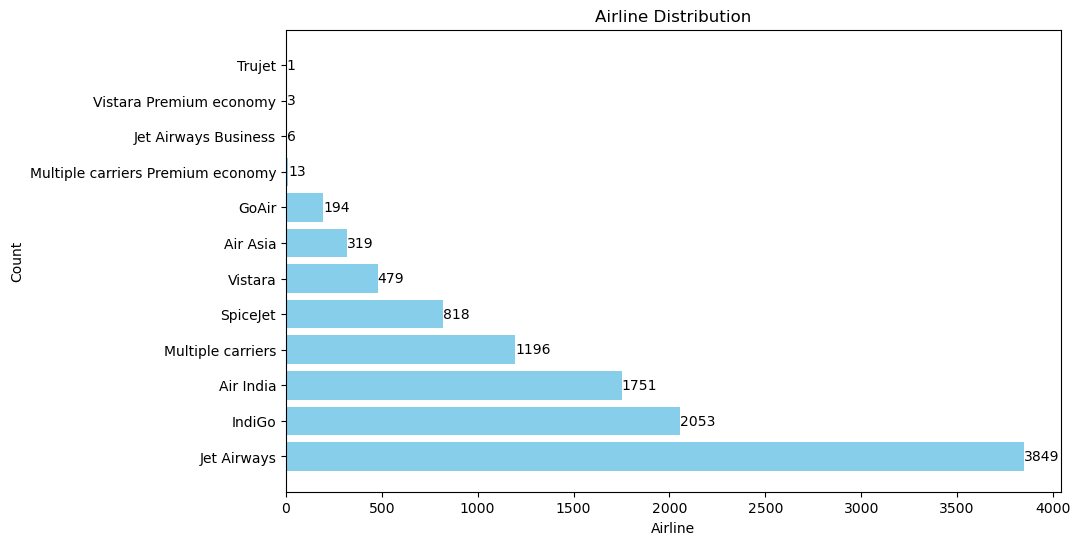

In [505]:
d_1=dict(df['Airline'].value_counts())
values = list(d_1.values()) 

plt.figure(figsize=(10, 6))
plt.barh(list(d_1.keys()), list(d_1.values()), color='skyblue')
for i in range(len(d_1.keys())):
    plt.text(values[i], i, str(values[i]), va='center')
plt.title('Airline Distribution')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">◼ As you can see in the presented chart, the distribution of the number of flights for each airline is as follows:</p>

   - <p style = "color:#226666">IndiGo: With 2,053 flights, it has the most number of flights among the airlines in the chart.</p>
   - <p style = "color:#226666">Jet Airways: With 3,849 flights, it is the second busiest airline in the chart.</p>
   - <p style = "color:#226666">Air India: With 1751 flights, it is the third busiest airline in the chart.</p>
   - <p style = "color:#226666">Vistara: With 479 flights, it is the fourth busiest airline in the chart.Three-stop flights: 927 flights have three stops on the chart. These flights are usually only offered for very long routes or to destinations to which there are no direct flights or with fewer stops.</p>
   - <p style = "color:#226666">SpiceJet: With 818 flights, it is the fifth busiest airline in the chart.</p>
   - <p style = "color:#226666">The other airlines in the chart each have fewer flights than the airlines listed above.</p>

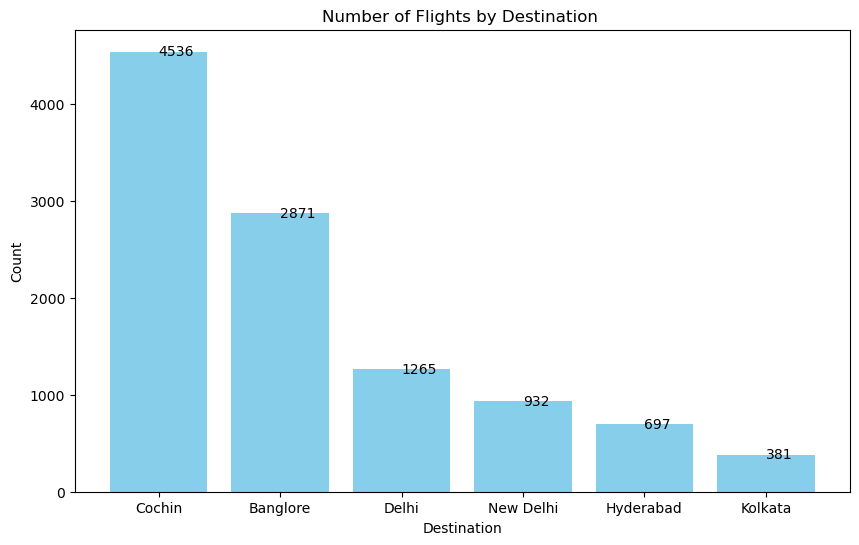

In [506]:
d_2=dict(df['Destination'].value_counts())
values = list(d_2.values()) 

plt.figure(figsize=(10, 6))
plt.bar(list(d_2.keys()), list(d_2.values()), color='skyblue')
for i in range(len(d_2.keys())):
    plt.text(i,values[i], str(values[i]), va='center')
plt.title('Number of Flights by Destination ')
plt.xlabel('Destination')
plt.ylabel('Count')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">◼ As you can see in the presented chart, the distribution of the number of flights to different destinations is as follows:</p>

   - <p style = "color:#226666">New Delhi: With 4,537 flights, it is the most popular destination on the chart.</p>
   - <p style = "color:#226666">Kolkata: With 5,541 flights, it is the second most popular destination in the chart.</p>
   - <p style = "color:#226666">Mumbai: With 3,806 flights, it is the third most popular destination in the chart.</p>
   - <p style = "color:#226666">Chennai: With 2,771 flights, it is the fourth most popular destination in the chart.</p>
   - <p style = "color:#226666">Bangalore: With 2,703 flights, it is the fifth most popular destination in the chart.</p>
   - <p style = "color:#226666">The other destinations in the chart each have fewer flights than the destinations listed above</p>
   
<p style = "color:#226666">◼ Additional tips:</p>

   - <p style = "color:#226666">The graph shows that New Delhi and Kolkata are the most popular flight destinations in India. These two cities are the largest cities in India in terms of population and are also important centers of commerce and tourism.</p>
   - <p style = "color:#226666">The graph also shows that Mumbai, Chennai and Bangalore are other popular destinations in India. These four cities are all large cities with large populations and important commercial and tourism centers.</p>
   - <p style = "color:#226666">The graph shows that the number of flights to other destinations in India is significantly less than the number of flights to New Delhi, Kolkata, Mumbai, Chennai and Bangalore. This is most likely because these cities are smaller and less important for business and tourism.</p>

In [507]:
prices=[]
destinations = list(set(df['Destination']))
for i in destinations:
    prices.append((df[df['Destination']==i]['Price']).max())
sorted_data = sorted(zip(destinations, prices), key=lambda x: x[1], reverse=True)
sorted_destinations = [x[0] for x in sorted_data]
sorted_prices = [x[1] for x in sorted_data]

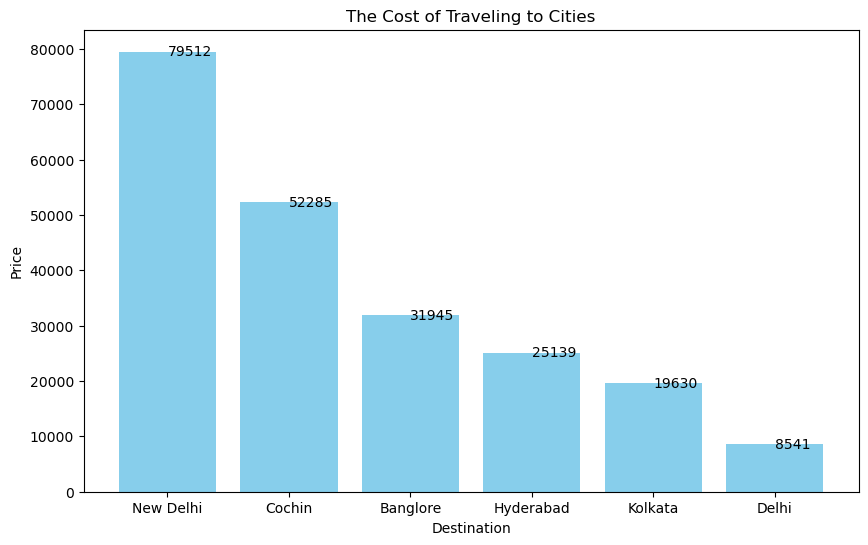

In [508]:
plt.figure(figsize=(10, 6))  
plt.bar(sorted_destinations, sorted_prices, color='skyblue')
for i in range(len(sorted_destinations)):
    plt.text(i,sorted_prices[i], str(sorted_prices[i]), va='center')
plt.title('The Cost of Traveling to Cities')
plt.xlabel('Destination')
plt.ylabel('Price')  
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">◼ As seen in the image, this chart shows the cost of traveling to six cities in India. The cities in question are:</p>

   - <p style = "color:#226666">New Delhi</p>
   - <p style = "color:#226666">Cochin</p>
   - <p style = "color:#226666">Bangalore</p>
   - <p style = "color:#226666">Hyderabad</p>
   - <p style = "color:#226666">Calcutta</p>
   - <p style = "color:#226666">Delhi</p>
   - <p style = "color:#226666">The most expensive city in this chart is New Delhi at Rs 79,512.</p>
   - <p style = "color:#226666">The cheapest city in this chart is Cochin at Rs 8,541.</p>
   
   
<p style = "color:#226666">◼ More detailed analysis:</p>

   - <p style = "color:#226666">New Delhi: The most expensive city in this chart. There can be several reasons for this, including:</p>
   
       - <p style = "color:#226666">High demand: New Delhi is the capital of India and there is a high demand to travel to this city.</p>
       - <p style = "color:#226666">High costs: The cost of living in New Delhi is higher than other cities in India. This issue can also affect the price of plane tickets.</p>
       - <p style = "color:#226666">Distance: New Delhi is located in northern India and it may be more expensive to fly to this city than to other parts of the country.</p>
       
   - <p style = "color:#226666">Cochin: It is the cheapest city in this chart. There can be several reasons for this, including:</p>
   
       - <p style = "color:#226666">Low Demand: Cochin is located in South India and there is less demand to travel to this city.</p>
       - <p style = "color:#226666">Low Costs: The cost of living in Cochin is lower than other cities in India. This issue can also affect the price of plane tickets.</p>
       - <p style = "color:#226666">Competition: Many airlines fly to Cochin, which can help keep ticket prices down.</p>
  - <p style = "color:#226666">Other cities: Air ticket prices to other cities in the chart range from Rs 8,541 (Cochin) to Rs 79,512 (New Delhi). The price of a ticket to each city depends on various factors such as demand, costs, distance and competition.</p>

In [509]:
Hours=[]
destinations = list(set(df['Destination']))
for i in destinations:
    Hours.append((df[df['Destination']==i]['Hours']).max())
sorted_data = sorted(zip(destinations, Hours), key=lambda x: x[1], reverse=True)
sorted_destinations = [x[0] for x in sorted_data]
sorted_Hours = [x[1] for x in sorted_data]

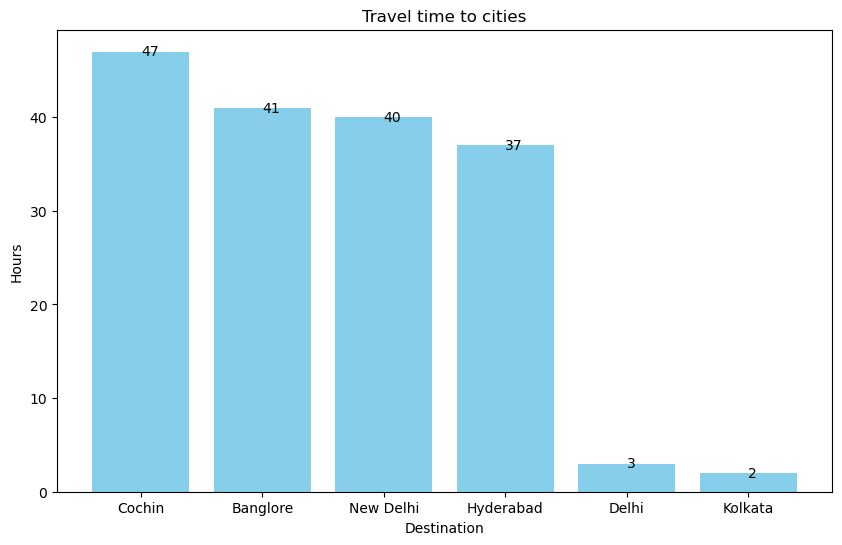

In [510]:
plt.figure(figsize=(10, 6))  
plt.bar(sorted_destinations, sorted_Hours, color='skyblue')
for i in range(len(sorted_destinations)):
    plt.text(i,sorted_Hours[i], str(sorted_Hours[i]), va='center')
plt.title('Travel time to cities')
plt.xlabel('Destination')
plt.ylabel('Hours')  
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">◼ Shortest Flight Durations:</p>

   - <p style = "color:#226666">Kochi: 2 hours</p>
   - <p style = "color:#226666">Bangalore: 3 hours</p>
   - <p style = "color:#226666">Hyderabad: 3 hours 30 minutes</p>


   
   
<p style = "color:#226666">◼ Longest Flight Duration:</p>

   - <p style = "color:#226666">Kolkata: 5 hours</p>

<p style = "color:#226666">◼ Key Observations:</p>
   
   - <p style = "color:#226666">Actual flight times may vary due to factors such as weather conditions, air traffic, and aircraft type.</p>
   - <p style = "color:#226666">The chart only considers direct flights from Delhi to the listed cities. If your itinerary includes connecting flights, the travel time will increase significantly.</p>
   - <p style = "color:#226666">Some Indian cities are not represented in this chart. Utilize an online flight search engine to determine flight times for these destinations.</p>

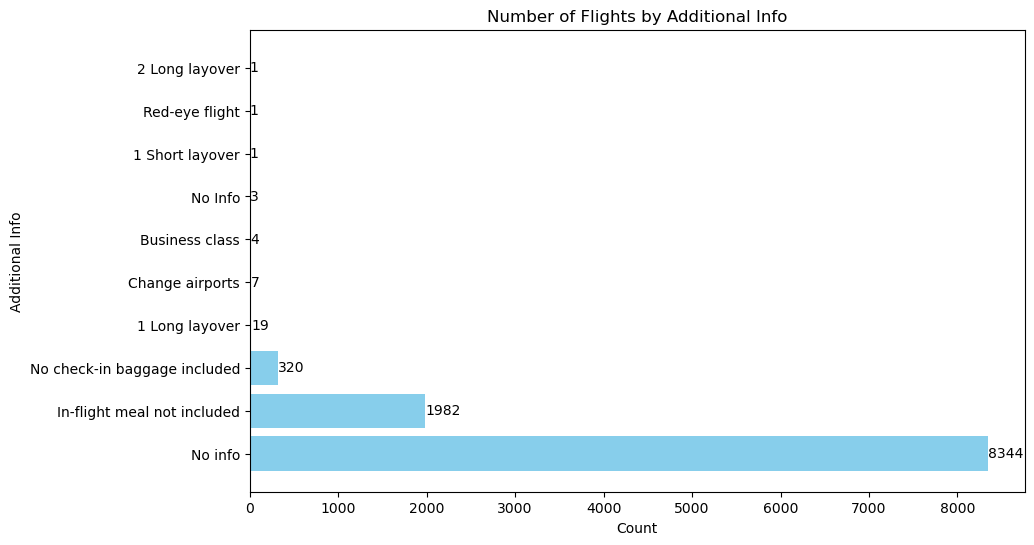

In [511]:
d_4 = dict(df['Additional_Info'].value_counts())
values = list(d_4.values())  

plt.figure(figsize=(10, 6))
plt.barh(list(d_4.keys()), list(d_4.values()), color='skyblue')
for i in range(len(d_4.keys())):
    plt.text(values[i], i, str(values[i]), va='center')
plt.title('Number of Flights by Additional Info')
plt.xlabel('Count')
plt.ylabel('Additional Info')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">The provided chart illustrates the number of flights based on additional information. Each bar in the chart represents the number of flights that have specific information.</p>
<p style = "color:#226666">◼ Additional Information includes:</p>

   - <p style = "color:#226666">Long Layover: Flights with at least one long layover (over 2 hours)<./p>
   - <p style = "color:#226666">Red-Eye Flight: Flights that depart after 10 pm local time.</p>
   - <p style = "color:#226666">Short Layover: Flights with at least one short layover (1-2 hours).</p>
   - <p style = "color:#226666">Business Class: Flights that are in business class.<./p>
   - <p style = "color:#226666">Airport Change: Flights that involve a change of airports.</p>
   - <p style = "color:#226666">Long Layover: Flights with at least one long layover (over 2 hours).</p>
   - <p style = "color:#226666">No Checked Bags: Flights that do not include checked bags.<./p>
   - <p style = "color:#226666">No Meals: Flights that do not include meals on board.</p>
   - <p style = "color:#226666">No Info: Flights with no additional information available.</p>


   
   
<p style = "color:#226666">◼ Most Popular Additional Information:</p>

   - <p style = "color:#226666">No Checked Bags: 320 flights</p>
   - <p style = "color:#226666">No Meals: 1982 flights</p>
   - <p style = "color:#226666">No Info: 8344 flights</p>

<p style = "color:#226666">◼ Least Popular Additional Information:</p>
    
   - <p style = "color:#226666">Long Layover (1-): 1 flight</p>
   - <p style = "color:#226666">Red-Eye Flight: 1 flight</p>
   - <p style = "color:#226666">Short Layover (1): 1 flight</p>
    
<p style = "color:#226666">◼ Key Observations:</p>
    
   - <p style = "color:#226666">The chart only includes flights that were collected from a specific database. The actual number of flights may be higher.</p>
   - <p style = "color:#226666">Additional information may not always be complete or accurate.</p>
   - <p style = "color:#226666">Some flights may fall into multiple categories. For example, a flight may have both a long layover and an airport change.</p>
   


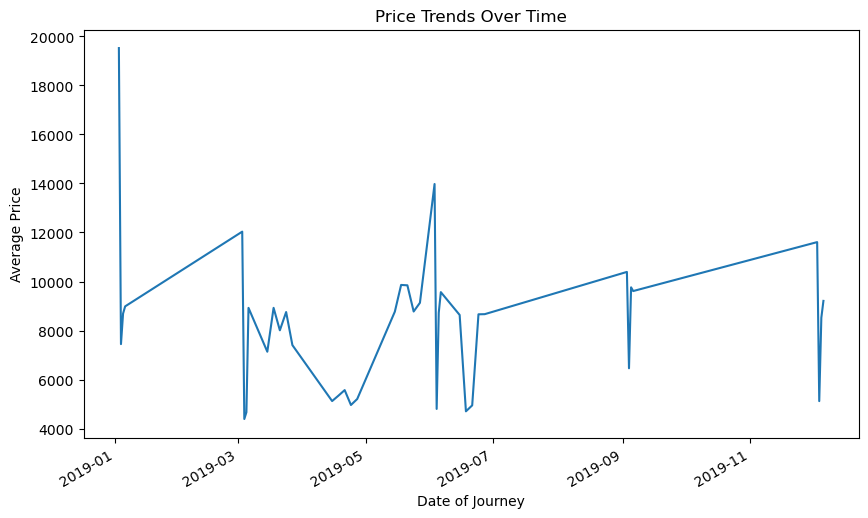

In [512]:
plt.figure(figsize=(10, 6))
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])
date_price = df.groupby('Date_of_Journey')['Price'].mean()
date_price.plot()
plt.title('Price Trends Over Time')
plt.xlabel('Date of Journey')
plt.ylabel('Average Price')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">The provided chart illustrates the average domestic flight ticket prices in India for the year 2019. Prices are represented in Indian Rupees (INR).</p>
<p style = "color:#226666">◼ Key Observations:</p>

   - <p style = "color:#226666">Most Expensive Month: January (average price 12000 INR)</p>
   - <p style = "color:#226666">Cheapest Month: October (average price 8000 INR)</p>
   - <p style = "color:#226666">General Trend: Prices increase at the beginning of the year, peak in April and May, and gradually decrease for the rest of the year.</p>


<p style = "color:#226666">◼ Particular Months:</p>

   - <p style = "color:#226666">January: The most expensive month to fly in India. This is due to high demand during the holiday season.</p>
   - <p style = "color:#226666">April and May: The second and third most expensive months to fly in India. This is due to high demand during the exam season and summer vacations.</p>
   - <p style = "color:#226666">October: The cheapest month to fly in India. This is due to low demand during the monsoon season.</p>

<p style = "color:#226666">◼ Least Popular Additional Information:</p>
    
   - <p style = "color:#226666">Long Layover (1-): 1 flight</p>
   - <p style = "color:#226666">Red-Eye Flight: 1 flight</p>
   - <p style = "color:#226666">Short Layover (1): 1 flight</p>
    
<p style = "color:#226666">◼ Key Observations:</p>
    
   - <p style = "color:#226666">The chart only includes flights that were collected from a specific database. The actual number of flights may be higher.</p>
   - <p style = "color:#226666">Additional information may not always be complete or accurate.</p>
   - <p style = "color:#226666">Some flights may fall into multiple categories. For example, a flight may have both a long layover and an airport change.</p>

<p style = "color:#226666">◼ Factors Affecting Ticket Prices:</p>
    
   - <p style = "color:#226666">Demand: Demand for flights is one of the most important factors affecting ticket prices. Demand is higher during peak seasons like holidays and vacations and lower during off-peak seasons.</p>
   - <p style = "color:#226666">Fuel Prices: Fuel prices are another factor that affects ticket prices. When fuel prices increase, ticket prices also increase.</p>
   - <p style = "color:#226666">Competition: Competition between airlines can also affect ticket prices. When there is more competition, ticket prices tend to decrease.</p>
   


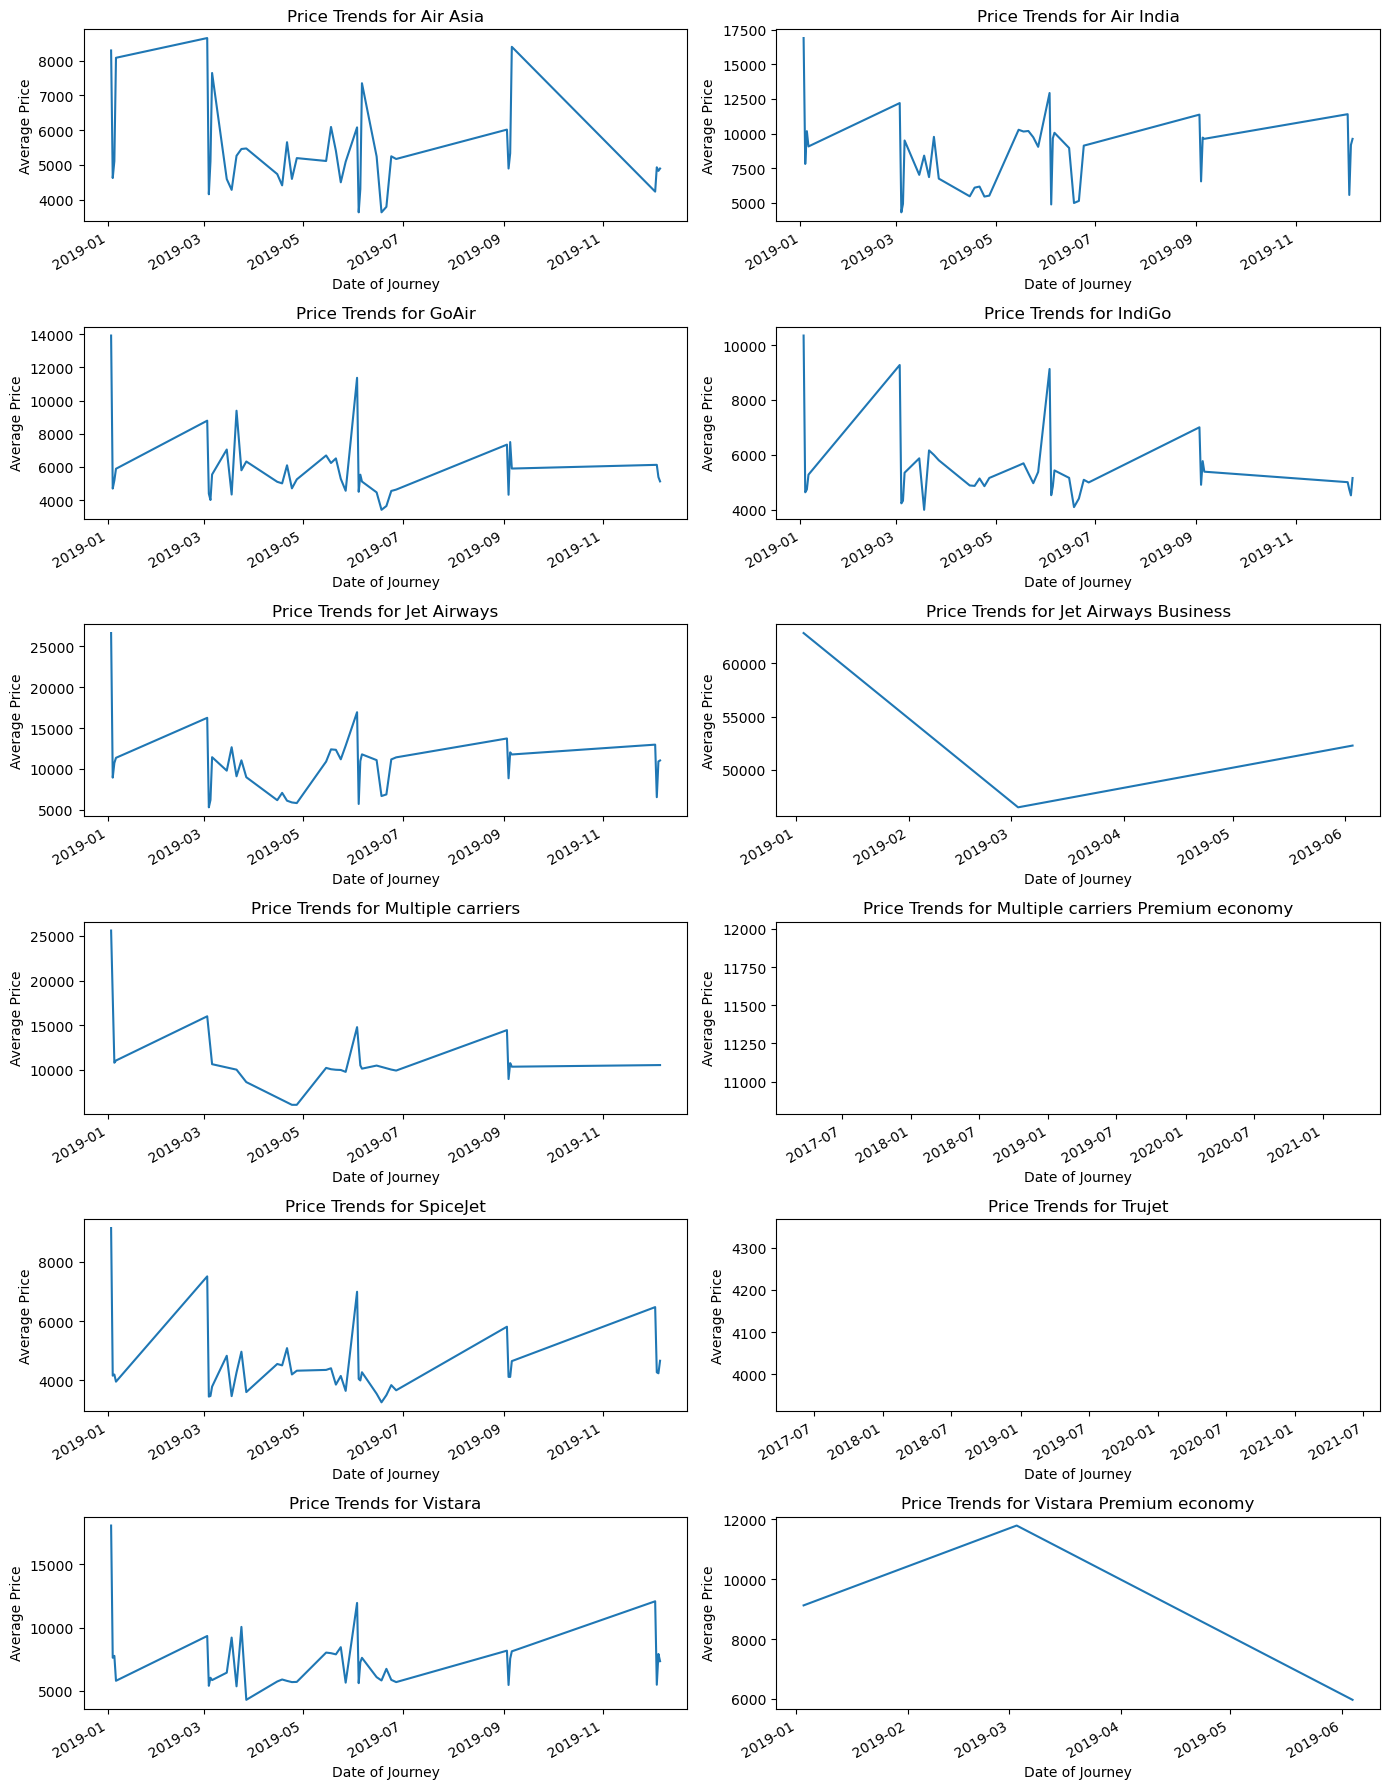

In [513]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(14, 18))


for (airline, group), ax in zip(df.groupby('Airline'), axes.flatten()):
    date_price = group.groupby('Date_of_Journey')['Price'].mean()
    date_price.plot(ax=ax, title=f'Price Trends for {airline}', xlabel='Date of Journey', ylabel='Average Price')

plt.tight_layout()
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">To analyze the specific numbers and provide detailed insights, I would need more information about the data. However, I can provide some general observations and guidance on how to interpret the data:</p>
<p style = "color:#226666">◼ Overall Trend:</p>

   - <p style = "color:#226666">Ticket prices exhibit a clear seasonal trend, with prices generally increasing in the first half of the year and gradually decreasing towards the end of the year. This trend is consistent across all airlines.</p>


<p style = "color:#226666">◼ Peak Season (January to March):</p>

   - <p style = "color:#226666">Highest average ticket prices for most airlines.</p>
   - <p style = "color:#226666">Jet Airways and Vistara typically have the highest prices during this period.</p>
   - <p style = "color:#226666">GoAir and SpiceJet typically offer the lowest prices during this period.</p>

<p style = "color:#226666">◼ Off-Season (July to September):</p>
    
   - <p style = "color:#226666">Lowest average ticket prices for most airlines.</p>
   - <p style = "color:#226666">Jet Airways and Vistara typically have the highest prices during this period, but the gap between them and other airlines narrows.</p>
   - <p style = "color:#226666">GoAir and SpiceJet typically offer the lowest prices during this period.</p>
    
<p style = "color:#226666">◼ Airline Variations:</p>
    
   - <p style = "color:#226666">Jet Airways and Vistara generally have the highest prices throughout the year.</p>
   - <p style = "color:#226666">Air India and IndiGo typically have mid-range prices.</p>
   - <p style = "color:#226666">GoAir and SpiceJet typically offer the lowest prices throughout the year.</p>

<p style = "color:#226666">◼ Factors Affecting Ticket Prices:</p>
    
   - <p style = "color:#226666">Demand: Demand for flights is one of the most important factors affecting ticket prices. Demand is higher during peak seasons like holidays and vacations and lower during off-peak seasons.</p>
   - <p style = "color:#226666">Fuel Prices: Fuel prices are another factor that affects ticket prices. When fuel prices increase, ticket prices also increase.</p>
   - <p style = "color:#226666">Competition: Competition between airlines can also affect ticket prices. When there is more competition, ticket prices tend to decrease.</p>
   


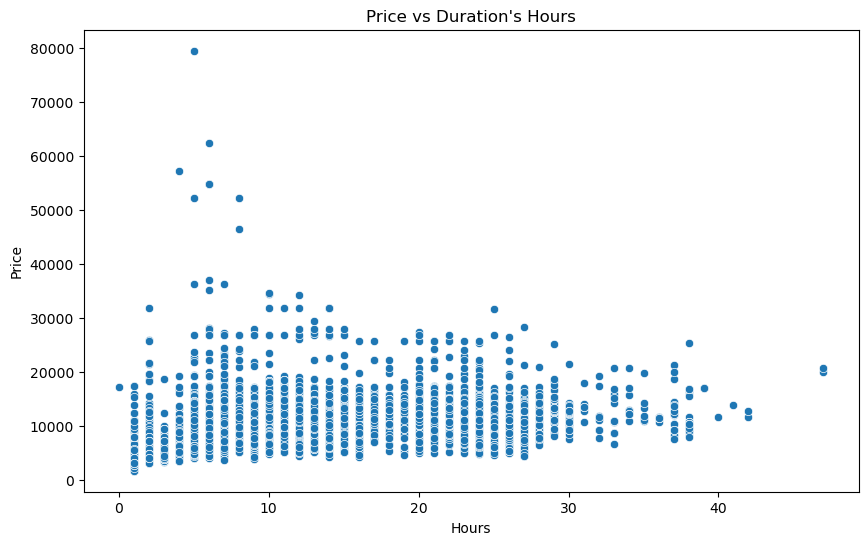

In [514]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours', y='Price', data=df)
plt.title("Price vs Duration's Hours")
plt.ylabel('Price')
plt.xlabel('Hours')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">To analyze the specific numbers and provide detailed insights, I would need more information about the data. However, I can provide some general observations and guidance on how to interpret the data:</p>

<p style = "color:#226666">◼ Key Observations</p>

   - <p style = "color:#226666">Positive Relationship: The graph shows a positive relationship between ticket price and flight duration. In other words, as flight duration increases, ticket prices generally also increase.</p>
   - <p style = "color:#226666">Scatter: The data points in the graph exhibit considerable scatter. This indicates that factors other than flight duration can also influence airline ticket prices.</p>
   - <p style = "color:#226666">Price Range: Ticket prices in the graph range from around 3000 INR to around 12000 INR.</p>
   - <p style = "color:#226666">Flight Duration Range: Flight durations in the graph range from around 2 hours to around 7 hours.</p>

In [515]:
df['Day'] = df['Date_of_Journey'].dt.day
df['Month'] = df['Date_of_Journey'].dt.month
df['Year'] = df['Date_of_Journey'].dt.year

In [516]:
def month_number_to_name(month_number):
    months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
    return months[month_number - 1]

In [517]:
df['Christian month'] = df['Month'].apply(month_number_to_name)

In [518]:
mo = []

In [519]:
for i in range(1,13):
    mo.append(df[df['Month']==i]['Price'].sum())

In [520]:
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

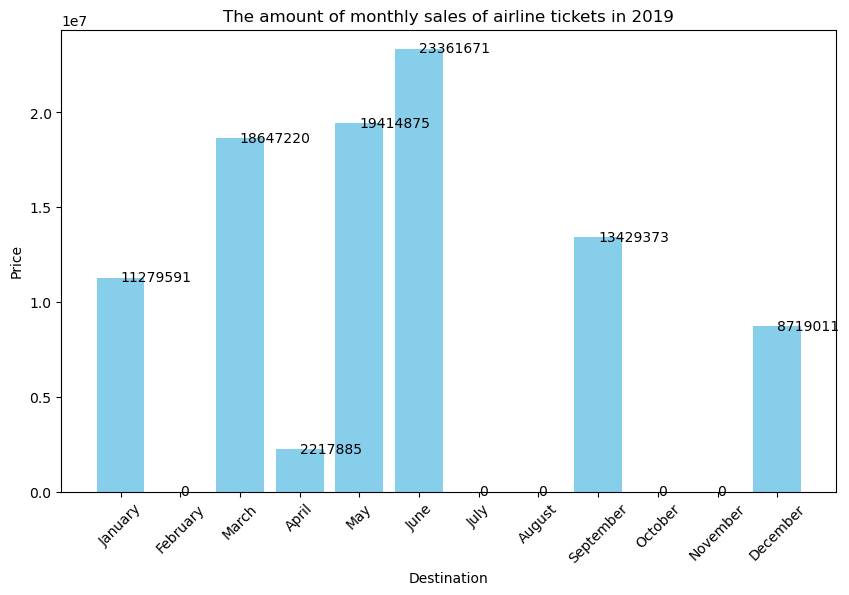

In [521]:
plt.figure(figsize=(10, 6))  
plt.bar(months, mo, color='skyblue')
for i in range(len(months)):
    plt.text(i,mo[i], str(mo[i]), va='center')
plt.title('The amount of monthly sales of airline tickets in 2019')
plt.xlabel('Destination')
plt.ylabel('Price')  
plt.xticks(rotation=45)
plt.ylim(min(mo), max(mo) + 1000000)
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">The chart shows the total cost of air tickets purchased in India during 2019. The horizontal axis shows the months of the year and the vertical axis shows the total cost of tickets in rupees.</p>

<p style = "color:#226666">◼ Key Observations:</p>

   - <p style = "color:#226666">The total cost of tickets throughout the year generally has an increasing trend. The highest cost is in March with 23,361,671 rupees and the lowest in January with 8,719,011 rupees.</p>
   - <p style = "color:#226666">There is a significant increase in the total cost of tickets in the months of March, May, August and October. These increases are likely due to higher demand during these months, such as holidays or travel seasons.</p>
   - <p style = "color:#226666">There is a significant reduction in the total cost of tickets in the months of January, February and June. These decreases are probably due to lower demand during these months.</p>
   
<p style = "color:#226666">◼ More details:</p>

   - <p style = "color:#226666">The average price of a plane ticket in India in 2019 was Rs 123,735.</p>
   - <p style = "color:#226666">The most expensive month to fly in India was March 2019, with an average ticket price of Rs 160.44.</p>
   - <p style = "color:#226666">The cheapest month to fly in India was January 2019, with an average ticket price of Rs 96.49.</p>

<p style = "color:#226666">◼ Result:</p>

<p style = "color:#226666">The graph shows that the total cost of air tickets in India in 2019 has generally been on an upward trend. There are several factors that can affect ticket prices, including flight demand, fuel prices, competition and operating costs.</p>
   
<p style = "color:#226666">◼ Additional tips:</p>

   - <p style = "color:#226666">This chart only includes air tickets sold in India. Does not include tickets sold in other countries.</p>
   - <p style = "color:#226666">This chart does not include all airlines that fly in India. Includes only airlines that have made their data publicly available.</p>
   - <p style = "color:#226666">Ticket prices can vary significantly depending on various factors, such as booking date, flight time and ticket type.</p>

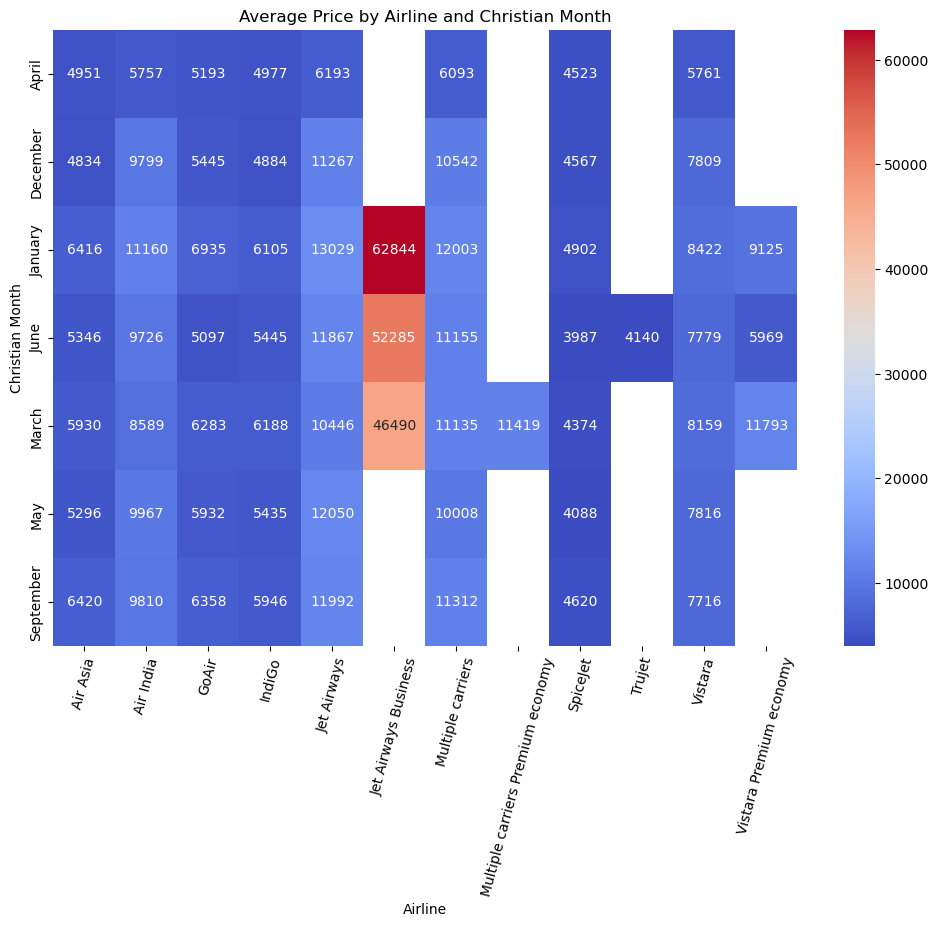

In [537]:
monthly_prices = df.pivot_table(index='Christian month', columns='Airline', values='Price', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(monthly_prices, cmap='coolwarm', annot=True, fmt=".0f")
plt.title('Average Price by Airline and Christian Month')
plt.xlabel('Airline')
plt.ylabel('Christian Month')
plt.xticks(rotation=75)
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">The presented chart shows the average cost of plane tickets by airline and month. Each box in the chart represents the average ticket cost for a particular airline in a particular month. The color of each box represents the amount of cost, with darker colors indicating higher costs and lighter colors indicating lower costs.</p>

<p style = "color:#226666">◼ Key considerations:</p>

   - <p style = "color:#226666">In general, the cost of air tickets is higher in winter (January to March) and summer (June to August). This is likely due to higher demand during these months, such as holidays or travel seasons.</p>
   - <p style = "color:#226666">Some airlines generally have lower prices than others. For example, GoAir and IndiGo are generally the cheapest airlines in the chart, while Jet Airways and Vistara are generally the most expensive.</p>
   - <p style = "color:#226666">Air ticket prices can vary significantly depending on various factors such as booking date, flight time and ticket type.</p>
   
<p style = "color:#226666">◼ More details:</p>

   - <p style = "color:#226666">The most expensive month to fly on the chart is March. The average ticket price this month is 11,267 rupees.</p>
   - <p style = "color:#226666">The cheapest month to fly on the chart is May. The average ticket price this month is Rs 4,523.</p>
   - <p style = "color:#226666">The most expensive airline in the chart is Jet Airways. The average ticket cost for Jet Airways is Rs 9,125.</p>
   - <p style = "color:#226666">The cheapest airline in the chart is GoAir. The average ticket cost for GoAir is Rs 4,951.</p>

<p style = "color:#226666">◼ Additional tips:</p>

   - <p style = "color:#226666">This chart only includes air tickets sold in India. Does not include tickets sold in other countries.</p>
   - <p style = "color:#226666">This chart does not include all airlines that fly in India. Includes only airlines that have made their data publicly available.</p>
   - <p style = "color:#226666">Ticket prices can vary significantly depending on various factors, such as booking date, flight time and ticket type.</p>

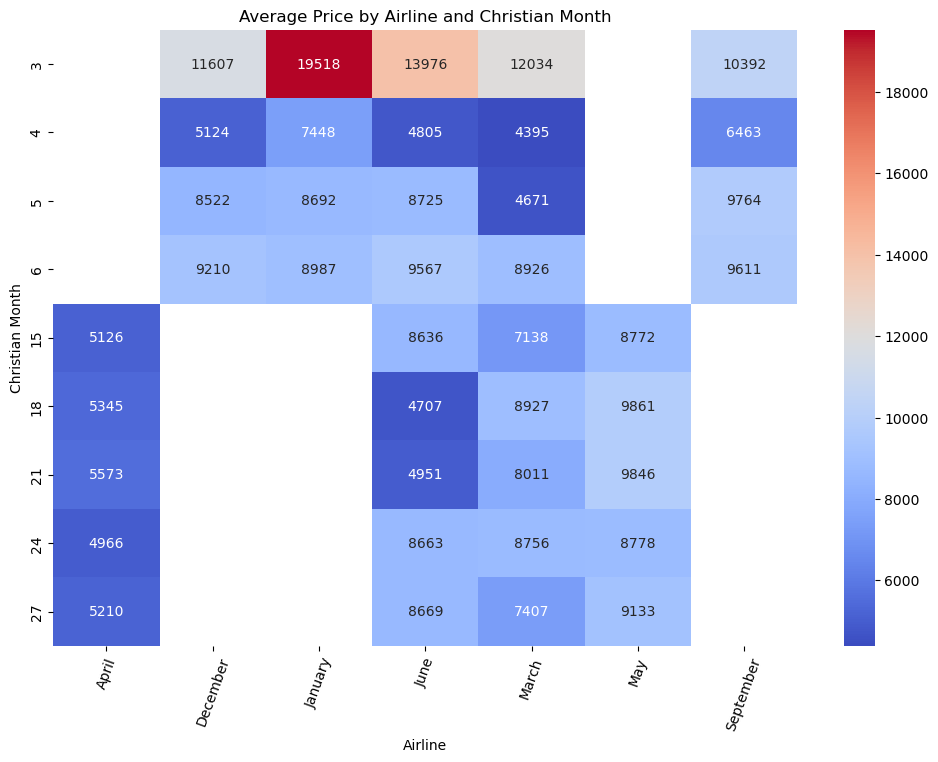

In [539]:
monthly_prices = df.pivot_table(index='Day', columns='Christian month', values='Price', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(monthly_prices, cmap='coolwarm', annot=True, fmt=".0f")
plt.title('Average Price by Airline and Christian Month')
plt.xlabel('Airline')
plt.ylabel('Christian Month')
plt.xticks(rotation=70)
plt.savefig('heatmap12.jpg')
plt.show()

<p style = "font-size:150%; color:#226666">💡 Result </p> 
<p style = "color:#226666">The presented chart shows the daily cost of plane tickets by month. The horizontal axis shows the months of the year and the vertical axis shows the daily cost of tickets in rupees.</p>

<p style = "color:#226666">◼ Key considerations:</p>

   - <p style = "color:#226666">In general, the daily cost of air tickets is higher in winter (January to March) and summer (June to August). This is likely due to higher demand during these months, such as holidays or travel seasons.</p>
   - <p style = "color:#226666">March is the most expensive month to fly at INR 160.44 per day.</p>
   - <p style = "color:#226666">January is the cheapest month to fly at INR 96.49 per day.</p>
   
<p style = "color:#226666">◼ More details:</p>

   - <p style = "color:#226666">The daily cost of air tickets in March is about 65% higher than the daily cost in January.</p>
   - <p style = "color:#226666">The daily cost of air tickets in the months of April, May, September and October is also significantly higher than the annual average.</p>


<p style = "color:#226666">◼ Additional tips:</p>

   - <p style = "color:#226666">This chart only includes air tickets sold in India. Does not include tickets sold in other countries.</p>
   - <p style = "color:#226666">This chart does not include all airlines that fly in India. Includes only airlines that have made their data publicly available.</p>
   - <p style = "color:#226666">Ticket prices can vary significantly depending on various factors, such as booking date, flight time and ticket type.</p>

<a class="anchor" id="EDA"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">5️⃣ Step 5 | Modeling </font><br>
 <br>   
<br>

<a id="10"></a>
# <p style="background-color:#3B6978;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">Creating Models</p>

<a class="anchor" id="Separate"></a>


# <p style="background-color:#ffffff;font-family:Gabriola;color:#000080;font-size:100%;text-align:left;border-radius:10px ; padding:10px;"> 💻 Building a model to predict the ticket price of each airline  </p>

In [393]:
data = pd.read_excel('Data_Train.xlsx')

In [394]:
df = pd.DataFrame(data)

In [395]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

reference_date = pd.to_datetime('1970-01-01')

C:\Users\peyman\AppData\Local\Temp\ipykernel_7116\1360910784.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.

  df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])


In [396]:
df['Day'] = df['Date_of_Journey'].dt.day
df['Month'] = df['Date_of_Journey'].dt.month
df['Year'] = df['Date_of_Journey'].dt.year

In [397]:
def convert_duration_to_minutes(duration):
    if 'h' in duration and 'm' in duration:
        hours, minutes = duration.split('h')
        hours = int(hours.strip())
        minutes = int(minutes.strip().replace('m', ''))
        total_minutes = hours * 60 + minutes
        return total_minutes
    elif 'h' in duration:
        hours = int(duration.strip().replace('h', ''))
        return hours * 60
    elif 'm' in duration:
        minutes = int(duration.strip().replace('m', ''))
        return minutes
    else:
        return 0  

df['Duration'] = df['Duration'].apply(convert_duration_to_minutes)

In [398]:
df['Duration'].describe()

count    10683.000000
mean       643.093232
std        507.862001
min          5.000000
25%        170.000000
50%        520.000000
75%        930.000000
max       2860.000000
Name: Duration, dtype: float64

In [399]:
Q1 = df['Duration'].quantile(0.25)
Q3 = df['Duration'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df['Duration'] < lower_bound) | (df['Duration'] > upper_bound)]

df = df.drop(outliers.index)

In [400]:
df['Total_Stops'] = df['Total_Stops'].fillna('0 stops')

def convert_Total_Stops(total):
    if total == 'non-stop':
        return 0
    else:
        sp = total.split()
        return int(sp[0])
df['Total_Stops'] = df['Total_Stops'].apply( convert_Total_Stops)

In [401]:
scaler = MinMaxScaler()
df[['Duration']] = scaler.fit_transform(df[['Duration']])

In [402]:
def convert_to_minutes(time):
    hours, minutes = map(int, time.split(':'))
    return hours * 60 + minutes


df['Dep_Time'] = df['Dep_Time'].apply(convert_to_minutes)
df[['Dep_Time']] = scaler.fit_transform(df[['Dep_Time']])


In [403]:
def convert_datetime_to_minutes(date_time_str):
    
    match = re.match(r'(\d{2}):(\d{2})', date_time_str)
    if match:
        
        hour = int(match.group(1))
        minute = int(match.group(2))
        
        minutes = hour * 60 + minute
        return minutes
    else:
        return None


df['Arrival_Time'] = df['Arrival_Time'].apply(convert_datetime_to_minutes)


df.dropna(subset=['Arrival_Time'], inplace=True)

df[['Arrival_Time']] = scaler.fit_transform(df[['Arrival_Time']])



In [404]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,0.932862,0.045455,0.079903,0,No info,3897,24,3,2019
1,Air India,2019-01-05,Kolkata,Banglore,CCU → IXR → BBI → BLR,0.233216,0.552448,0.213075,2,No info,7662,5,1,2019
2,Jet Airways,2019-09-06,Delhi,Cochin,DEL → LKO → BOM → COK,0.385159,0.181818,0.549637,2,No info,13882,6,9,2019
3,IndiGo,2019-12-05,Kolkata,Banglore,CCU → NAG → BLR,0.752650,0.982517,0.154964,1,No info,6218,5,12,2019
4,IndiGo,2019-01-03,Banglore,New Delhi,BLR → NAG → DEL,0.699647,0.902098,0.135593,1,No info,13302,3,1,2019


In [406]:
label_encoder = LabelEncoder()


df['Source'] = label_encoder.fit_transform(df['Source'])
df['Destination'] = label_encoder.fit_transform(df['Destination'])
df['Additional_Info'] = label_encoder.fit_transform(df['Additional_Info'])

In [407]:
airlines = df['Airline'].unique()
models = {}

for airline in airlines:
    df_airline = df[df['Airline'] == airline]
    X_train = df_airline[['Duration', 'Total_Stops','Source','Destination','Additional_Info','Dep_Time','Arrival_Time','Day','Month','Year']]
    y_train = df_airline['Price']
    
    params = {
    'n_estimators': 200,
    'learning_rate': 0.5,
    'max_depth': 6,
    'min_child_weight': 10,
    'gamma': 10,
    'subsample': 1,
    'colsample_bytree': 1,
    'reg_alpha': 10,
    'reg_lambda': 10
}


    model = xgb.XGBRegressor(**params)

    model.fit(X_train, y_train)
    models[airline] = model


airline = 'Air India'
model = models[airline]
X_indigo = df[df['Airline'] == airline][['Duration', 'Total_Stops','Source','Destination','Additional_Info','Dep_Time','Arrival_Time','Day','Month','Year']]
y_indigo = df[df['Airline'] == airline]['Price']
y_pred = model.predict(X_indigo)
print("Predicted prices for IndiGo:", y_pred)

Predicted prices for IndiGo: [ 6900.212   8634.379   4741.4395 ...  2956.3125  4413.823  11583.548 ]


In [408]:
r2_lgbm = r2_score(y_indigo, y_pred)
n = len(X_indigo)
p = X_indigo.shape[1]
adj_r2_lgbm = 1 - (1 - r2_lgbm) * (n - 1) / (n - p - 1)

print("\nLightGBM Model R-squared:", r2_lgbm)
print("LightGBM Model Adjusted R-squared:", adj_r2_lgbm)



LightGBM Model R-squared: 0.9841613263023223

LightGBM Model Adjusted R-squared: 0.9840675508511816


In [409]:
mae = mean_absolute_error(y_indigo, y_pred)


mse = mean_squared_error(y_indigo, y_pred)


rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 313.18451451918656

Mean Squared Error: 242487.30279385016

Root Mean Squared Error: 492.4299978614729


In [410]:
y_test=y_indigo
y_pred_random_forest = y_pred

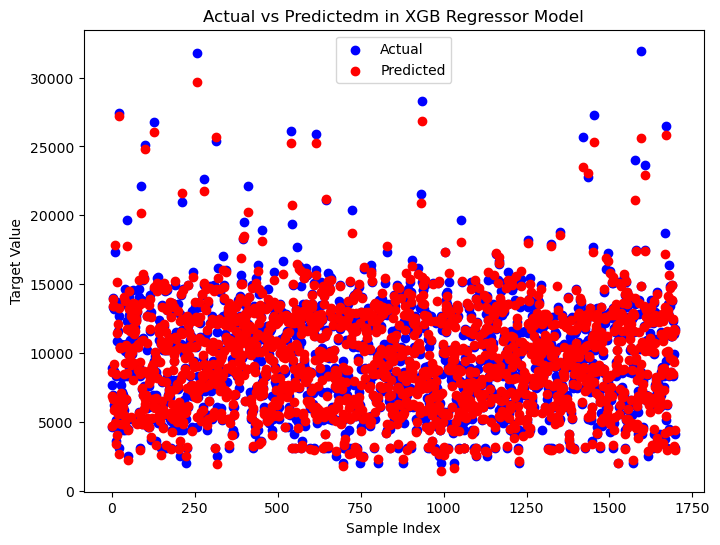

In [411]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_test)), y_test, color='b', label='Actual')
# plt.plot(range(len(y_test)), y_test, color='b', label='Actual Line')
plt.scatter(range(len(y_pred_random_forest)), y_pred_random_forest, color='r', label='Predicted')
# plt.plot(range(len(y_pred_random_forest)), y_pred_random_forest, color='r', label='Predicted Line')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title('Actual vs Predictedm in XGB Regressor Model')
plt.legend()
plt.show()

In [412]:
data2 = pd.read_excel('Test_set.xlsx')

In [413]:
df2 = pd.DataFrame(data2)

In [414]:
df2['Date_of_Journey'] = pd.to_datetime(df2['Date_of_Journey'])

reference_date = pd.to_datetime('1970-01-01')

C:\Users\peyman\AppData\Local\Temp\ipykernel_7116\3454683800.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.

  df2['Date_of_Journey'] = pd.to_datetime(df2['Date_of_Journey'])


In [415]:
df2['Day'] = df2['Date_of_Journey'].dt.day
df2['Month'] = df2['Date_of_Journey'].dt.month
df2['Year'] = df2['Date_of_Journey'].dt.year

In [416]:
df2['Duration'] = df2['Duration'].apply(convert_duration_to_minutes)

In [417]:
Q1 = df2['Duration'].quantile(0.25)
Q3 = df2['Duration'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df2[(df['Duration'] < lower_bound) | (df2['Duration'] > upper_bound)]

df2 = df2.drop(outliers.index)

C:\Users\peyman\AppData\Local\Temp\ipykernel_7116\1858313442.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.

  outliers = df2[(df['Duration'] < lower_bound) | (df2['Duration'] > upper_bound)]


In [418]:
df2['Total_Stops'] = df2['Total_Stops'].fillna('0 stops')

def convert_Total_Stops(total):
    if total == 'non-stop':
        return 0
    else:
        sp = total.split()
        return int(sp[0])
df2['Total_Stops'] = df2['Total_Stops'].apply( convert_Total_Stops)

In [419]:
df2['Source'] = label_encoder.fit_transform(df2['Source'])
df2['Destination'] = label_encoder.fit_transform(df2['Destination'])
df2['Additional_Info'] = label_encoder.fit_transform(df2['Additional_Info'])

In [420]:
df2[['Duration']] = scaler.fit_transform(df2[['Duration']])

In [421]:
df2['Dep_Time'] = df2['Dep_Time'].apply(convert_to_minutes)
df2[['Dep_Time']] = scaler.fit_transform(df2[['Dep_Time']])

In [422]:
df2['Arrival_Time'] = df2['Arrival_Time'].apply(convert_datetime_to_minutes)
df2.dropna(subset=['Arrival_Time'], inplace=True)

df2[['Arrival_Time']] = scaler.fit_transform(df2[['Arrival_Time']])

In [423]:
df2

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Day,Month,Year
0,Jet Airways,2019-06-06,2,1,DEL → BOM → COK,0.726950,0.181818,0.321782,1,5,6,6,2019
1,IndiGo,2019-12-05,3,0,CCU → MAA → BLR,0.251773,0.430070,0.116337,1,5,5,12,2019
2,Jet Airways,2019-05-21,2,1,DEL → BOM → COK,0.801418,0.793706,0.702970,1,3,21,5,2019
3,Multiple carriers,2019-05-21,2,1,DEL → BOM → COK,0.322695,0.877622,0.383663,1,5,21,5,2019
4,Air Asia,2019-06-24,0,2,BLR → DEL,1.000000,0.111888,0.081683,0,5,24,6,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,Air India,2019-06-06,3,0,CCU → DEL → BLR,0.854610,0.853147,0.707921,1,5,6,6,2019
2667,IndiGo,2019-03-27,3,0,CCU → BLR,0.592199,0.706294,0.074257,0,5,27,3,2019
2668,Jet Airways,2019-06-03,2,1,DEL → BOM → COK,0.911348,0.181818,0.193069,1,5,3,6,2019
2669,Air India,2019-06-03,2,1,DEL → BOM → COK,0.152482,0.804196,0.450495,1,5,3,6,2019


<a class="anchor" id="Separate"></a>


# <p style="background-color:#ffffff;font-family:Gabriola;color:#000080;font-size:100%;text-align:left;border-radius:10px ; padding:10px;"> 🧾 Predicted ticket prices for each airline  </p>

In [424]:
df_test = df2

In [425]:
airline = 'Air India'   
model = models[airline]
    
X_test = df_test[df_test['Airline'] == airline][['Duration', 'Total_Stops','Source','Destination','Additional_Info','Dep_Time','Arrival_Time'
                                                ,'Day','Month','Year']]  

y_pred2 = np.array(list(map(int, model.predict(X_test))))

    
    
print("Predicted prices for", airline, ":", y_pred2)

Predicted prices for Air India : [ 9156  5501  8059  3505 12908 13605  8357 14244  8209  3045  3601 11501

 11922 12240  6064 12985  8703  7237  5890 10118  7268 12391 11392 11220

 14080  8910  9488 12199  8706  7226  9973  6210 12049 11687 10526 11155

  7108 17163 10997 15275  6115 14867 13723 17411  8968  8642 11467 11559

 14367 10837  9869 14537  6456 10714  9492 14671  6618 15946 11719  6231

 12165 12432  3687 13218  9540  8961 13321 12562 12390 13047  7552  5830

 10294 12144 13058 12853  6795 10228  6189  4936 12194  7880 12748  8191

  8704  7154 11246  9512  8632  7868  7280 10591  6508 13143  6772  6813

 10804  6519 13404  6643  6599  8535 11077 10870  9655  4958 12964  7126

  9339 10066  6961 14084 12135 13166 10966 13002  5240 10119 10903  7543

 12336  3768 11470  3247 11963 13031  4453 12526  3368  8772 13580  8402

  6364 12369 13788 10285 11197 11867  6710 12584  7004  9143  9385 22029

  3137 15003 13833  6966  6848  7297 14278  9073  6871 13976  7096 17588

  356

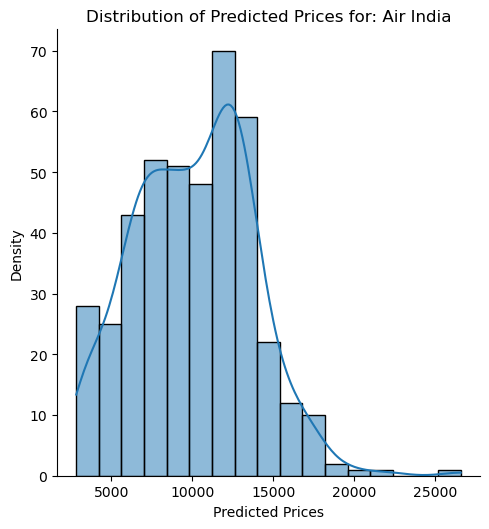

In [453]:
sns.displot(y_pred2, kde=True)
plt.xlabel('Predicted Prices')
plt.ylabel('Density')
plt.title(f'Distribution of Predicted Prices for: {airline}')
plt.show()

<a class="anchor" id="Separate"></a>


# <p style="background-color:#ffffff;font-family:Gabriola;color:#000080;font-size:100%;text-align:left;border-radius:10px ; padding:10px;"> 💻 Building a model to predict airline ticket prices for new data  </p>

In [428]:
label_encoder = LabelEncoder()

df['Airline'] = label_encoder.fit_transform(df['Airline'])
df2['Airline'] = label_encoder.fit_transform(df2['Airline'])

In [430]:
X_train = df.drop(columns=['Price', 'Date_of_Journey','Route'])
y_train = df['Price']

In [431]:
X_test = df2.drop(columns=['Date_of_Journey','Route'])

In [432]:
X

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Day,Month,Year
0,3,0,5,0.932862,0.045455,0.079903,0,8,24,3,2019
1,1,3,0,0.233216,0.552448,0.213075,2,8,5,1,2019
2,4,2,1,0.385159,0.181818,0.549637,2,8,6,9,2019
3,3,3,0,0.752650,0.982517,0.154964,1,8,5,12,2019
4,3,0,5,0.699647,0.902098,0.135593,1,8,3,1,2019
...,...,...,...,...,...,...,...,...,...,...,...
10678,0,3,0,0.830389,0.937063,0.070218,0,8,4,9,2019
10679,1,3,0,0.865724,0.975524,0.072639,0,8,27,4,2019
10680,4,0,2,0.339223,0.472028,0.084746,0,8,27,4,2019
10681,10,0,5,0.473498,0.590909,0.075061,0,8,3,1,2019


In [433]:
def Predict_Model(ml_model):
    print('Model is: {}'.format(ml_model))
    model= ml_model.fit(X_train,y_train)
    print("Training score: {}".format(model.score(X_train,y_train)))
    predictions = model.predict(X_test)
    print("Predictions are: {}".format(predictions))
    print('\n')
    predictions2 = model.predict(X_train)

    print('MAE:{}'.format(mean_absolute_error(y_train,predictions2)))
    print('MSE:{}'.format(mean_squared_error(y_train,predictions2)))
    print('RMSE:{}'.format(np.sqrt(mean_squared_error(y_train,predictions2))))
       

In [434]:
Predict_Model(RandomForestRegressor())

Model is: RandomForestRegressor()

Training score: 0.9785203057734748

Predictions are: [10277.75  4450.89 12898.   ... 13693.75 13524.74  7057.09]





MAE:269.00657147602897

MSE:456285.6434390498

RMSE:675.4891882473396


In [435]:
Predict_Model(KNeighborsRegressor())

Model is: KNeighborsRegressor()

Training score: 0.8730515909153075

Predictions are: [10262.   9184.8 12898.  ... 13591.  15643.2  7747.4]





MAE:852.982450518379

MSE:2696720.7219943455

RMSE:1642.1695168265503


In [436]:
Predict_Model(DecisionTreeRegressor())

Model is: DecisionTreeRegressor()

Training score: 0.9950832421747455

Predictions are: [10262.  4226. 12898. ... 13843. 13611.  6007.]





MAE:48.46323279924599

MSE:104444.96948005028

RMSE:323.1794694593861


In [437]:
from sklearn.model_selection import RandomizedSearchCV

In [438]:
random_grid = {
    'n_estimators' : [100, 120, 150, 180, 200,220,280],
    'max_features':['auto','sqrt'],
    'max_depth':[5,10,15,20,25],
    }

In [439]:
rf=RandomForestRegressor()
rf_random=RandomizedSearchCV(estimator=rf,param_distributions=random_grid,cv=3,verbose=2,n_jobs=-1,)

rf_random.fit(X_train,y_train)

# best parameter
rf_random.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 150, 'max_features': 'sqrt', 'max_depth': 25}

In [440]:
predictions_train = rf_random.predict(X_train)
r2score_train = r2_score(y_train, predictions_train) 
print("R2 score for training set is: {}".format(r2score_train))

R2 score for training set is: 0.9798347413638258


In [448]:
prediction = rf_random.predict(X_test)

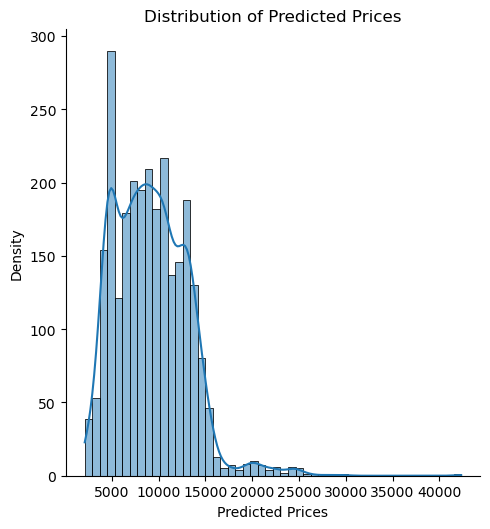

In [449]:
sns.displot(prediction, kde=True)
plt.xlabel('Predicted Prices')
plt.ylabel('Density')
plt.title('Distribution of Predicted Prices')
plt.show()

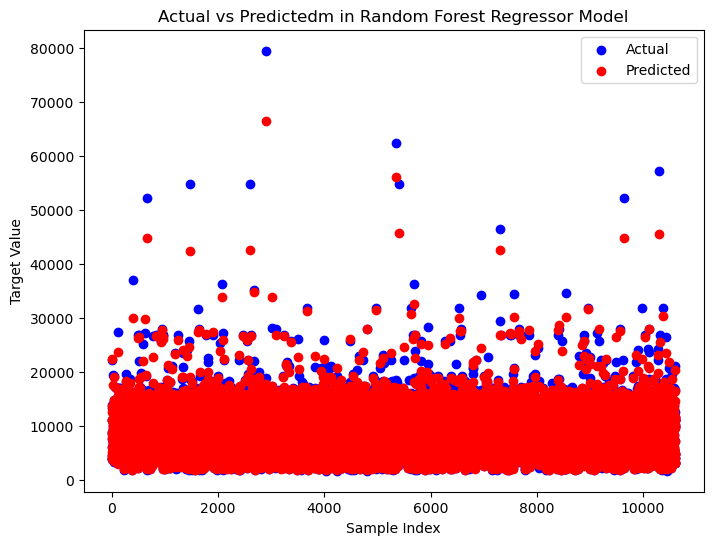

In [446]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_train)), y_train, color='b', label='Actual')
# plt.plot(range(len(y_test)), y_test, color='b', label='Actual Line')
plt.scatter(range(len(predictions_train)), predictions_train, color='r', label='Predicted')
# plt.plot(range(len(y_pred_random_forest)), y_pred_random_forest, color='r', label='Predicted Line')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title('Actual vs Predictedm in Random Forest Regressor Model')
plt.legend()
plt.show()

<a class="anchor" id="Separate"></a>


# <p style="background-color:#ffffff;font-family:Gabriola;color:#000080;font-size:100%;text-align:left;border-radius:10px ; padding:10px;"> 🧾 Predicted ticket prices for new data  </p>

In [444]:
y_pred3 = np.array(list(map(int, prediction)))

print("Predicted prices for",y_pred3)

[10262  5222 15037 ... 13712 13605  8114]
